In [2]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import cm
import json
import seaborn as sns
import plot_utils
import glob

In [4]:
sns.set_palette("coolwarm")
colors = sns.color_palette("coolwarm", 10)

In [5]:
temperatures = [-40,-30, -20,-10, 0, 25]

In [6]:
devices = ['LMG405', 'LMG450', 'LMG365', 'LMG520', 'KAPU465', 'KAPU405']

In [7]:
pocam =  8
hem1 = 23
hem2 = 24
batch=  'batch1'

In [8]:
n_photons_dict = {}

file_basepath_hem1 = f'../output/{batch}/pocam_{pocam:03d}/hem_{hem1:.0f}/'
file_basepath_hem2 = f'../output/{batch}/pocam_{pocam:03d}/hem_{hem2:.0f}/'

files = [file_basepath_hem1, file_basepath_hem2]
for file in files:
    for d in devices:
        n_photons = np.zeros((len(temperatures), 2))
        for i, t in enumerate(temperatures):
            if f'{hem1:.0f}' in file:
                hem = hem1
            if f'{hem2:.0f}' in file:
                hem = hem2
            if 'LMG' in d:
                suffix = '1-20'
            else:
                suffix = 'default'
        
            with open(file+f'{d}/photons_54000_{t:.0f}C_{suffix}.json', "r") as f:
                data = json.load(f)

            n_photons[i][0] = data['meas_data'][0]['value'] 
            n_photons[i][1] = data['meas_data'][0]['error']*data['meas_data'][0]['value']
                        
        n_photons_dict[f'{d}_{hem:.0f}'] = n_photons

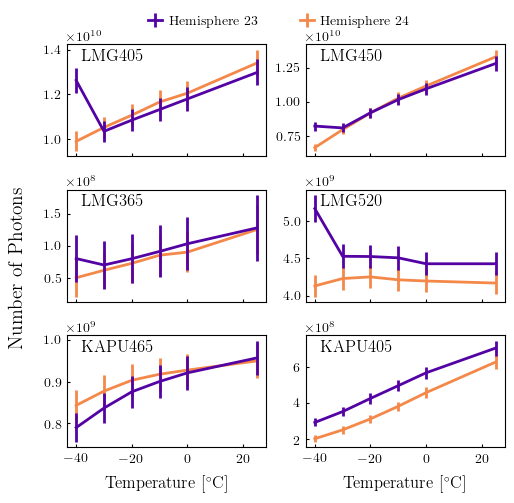

In [9]:
fig, axes = plt.subplots(3, 2, figsize=plot_utils.set_size('wide', fraction=.8, subplots=(3, 2)), sharex = True)

for i, ax in enumerate(axes.flat):
    d = devices[i]
    ax.errorbar(temperatures, n_photons_dict[f'{d}_{hem1:.0f}'][:,0], n_photons_dict[f'{d}_{hem1:.0f}'][:,1], 
                color = sns.color_palette()[0], zorder = 100,
                label=f'Hemisphere {hem1:.0f}')
    ax.errorbar(temperatures, n_photons_dict[f'{d}_{hem2:.0f}'][:,0], n_photons_dict[f'{d}_{hem2:.0f}'][:,1], 
                color = sns.color_palette()[4], alpha = 1,
                label=f'Hemisphere {hem2:.0f}')
    ax.text(0.07,0.85,f'{d}',transform = ax.transAxes)

    if i in [4, 5]:
        ax.set_xlabel(r'Temperature [$^\circ$C]')

axes[0][0].set_ylabel("Number of Photons", y=-1, size=14, labelpad=12)

# Single legend from the first subplot's handles, placed above the figure
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.96),
          columnspacing=3.0)

fig.subplots_adjust(hspace=0.3, wspace=0.2)
plt.savefig(f'plots/png/number_of_photons_pocam{pocam}.png', bbox_inches='tight')
plt.savefig(f'plots/pdf/number_of_photons_pocam{pocam}.pdf', bbox_inches='tight')

In [10]:
temperatures = [-40,-30, -20,-10, 0]

In [11]:
c_subset = sns.color_palette("plasma", 5)

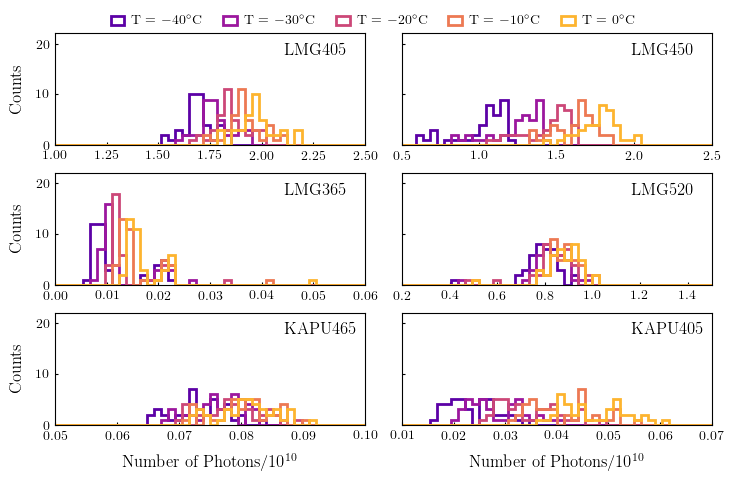

In [12]:
#now let's select all the number of emitter photons for a device and for a temperature and see the distribution
fig, axes = plt.subplots(3,2,figsize=plot_utils.set_size('wide', fraction=1.2, ratio= 0.4, subplots=(3, 2)), sharey=True)
for i, ax in enumerate(axes.flat):
    device = devices[i]
    n = 45
    if device == 'LMG450':
        bins = np.linspace(.5,2.5, n )
        ax.set_xlim(0.5,2.5)
    if device == 'LMG405':
        bins = np.linspace(1,2.5, n )
        ax.set_xlim(1,2.5)
    if device == 'LMG520':
        bins = np.linspace(0.2,1.5, n )
        ax.set_xlim(0.2,1.5)
    if device == 'LMG365':
        bins = np.linspace(0.,0.06,n)
        ax.set_xlim(0,0.06)
    if device == 'KAPU465':
        bins = np.linspace(0.05,0.1,n)
        ax.set_xlim(0.05,.1)
    if device == 'KAPU405':
        bins = np.linspace(0.01,0.07,n)
        ax.set_xlim(0.01,0.07)
        
    for j, T in enumerate(temperatures):
        if 'LMG' in device:
            path = f'../output/batch2/pocam_*/hem_*/{device}/photons_54000_{T:.0f}C_2-20.json'
        elif "KAPU" in device:
            path = f'../output/batch2/pocam_*/hem_*/{device}/photons_54000_{T:.0f}C_default.json'

        filelist = glob.glob(path)

        n_photons_distr = []
        for file in filelist:
            with open(file, "r") as f:
                data = json.load(f)
            n_photons_distr.append(data['meas_data'][0]['value'])
    
        ax.hist(np.array(n_photons_distr)/10**10, bins = bins, histtype = 'step', lw = 2, color = c_subset[j],label = f'T = ${T:.0f}^\circ$C')

        ax.set_ylim(0, 22)
        
    if i in [4,5]:
        ax.set_xlabel(r'Number of Photons$/10^{10}$')
    if i in [0,2,4]:
        ax.set_ylabel('Counts')
        
    
    ax.text(0.74,0.8, f'{device}', transform = ax.transAxes)
    
handles, labels = axes.flat[0].get_legend_handles_labels()    
fig.legend(handles, labels, loc='upper center', ncol=len(temperatures), bbox_to_anchor=(0.5, 0.94),
          columnspacing=1.5)
fig.subplots_adjust(hspace=0.25, wspace=.12)

plt.savefig(f'plots/png/number_of_photons_distr_all_Temperatures.png')
plt.savefig(f'plots/pdf/number_of_photons_distr_all_Temperatures.pdf')    

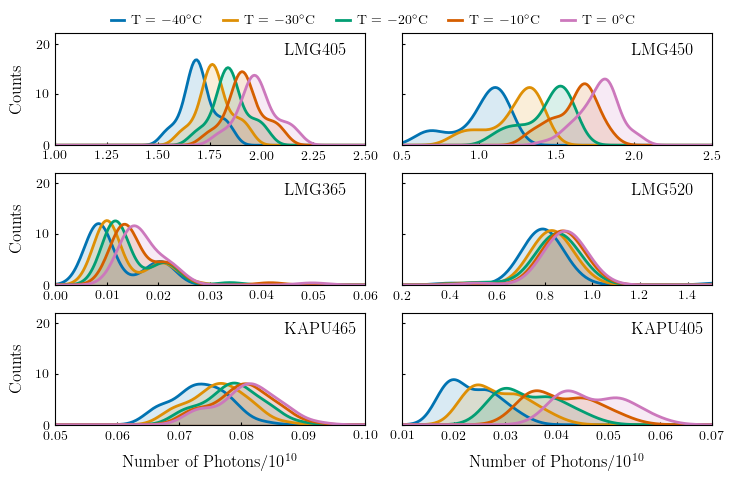

In [43]:
from scipy.stats import gaussian_kde

# Wong (2011) colorblind-safe categorical palette — 7 colors
wong_colors = [
    '#E69F00',  # orange
    '#56B4E9',  # sky blue
    '#009E73',  # bluish green
    '#F0E442',  # yellow
    '#0072B2',  # blue
    '#D55E00',  # vermillion
    '#CC79A7',  # reddish purple
]
# c_subset = wong_colors[:len(temperatures)]
c_subset = sns.color_palette('colorblind')

# colors = ['#d7191c','#fdae61','#ffffbf','#abd9e9','#2c7bb6']
# c_subset = colors[:len(temperatures)][::-1]


fig, axes = plt.subplots(3, 2,
                         figsize=plot_utils.set_size('wide', fraction=1.2, ratio=0.4, subplots=(3, 2)),
                         sharey=True)

x_ranges = {
    'LMG450':  (0.5,  2.5),
    'LMG405':  (1.0,  2.5),
    'LMG520':  (0.2,  1.5),
    'LMG365':  (0.0,  0.06),
    'KAPU465': (0.05, 0.1),
    'KAPU405': (0.01, 0.07),
}

for i, ax in enumerate(axes.flat):
    device = devices[i]
    xlo, xhi = x_ranges[device]
    ax.set_xlim(xlo, xhi)

    for j, T in enumerate(temperatures):
        if 'LMG' in device:
            path = f'../output/batch2/pocam_*/hem_*/{device}/photons_54000_{T:.0f}C_2-20.json'
        elif 'KAPU' in device:
            path = f'../output/batch2/pocam_*/hem_*/{device}/photons_54000_{T:.0f}C_default.json'

        filelist = glob.glob(path)

        n_photons_distr = []
        for file in filelist:
            with open(file, 'r') as f:
                data = json.load(f)
            n_photons_distr.append(data['meas_data'][0]['value'])

        vals = np.array(n_photons_distr) / 1e10
        color = c_subset[j]

        # KDE curve
        # KDE curve
        if len(vals) > 1:
            kde = gaussian_kde(vals, bw_method='scott')
            x_eval = np.linspace(xlo, xhi, 200)
            y_kde  = kde(x_eval)
            
            bin_width = (xhi - xlo) / 20      # <-- correct scaling
            y_kde_scaled = y_kde * len(vals) * bin_width

            ax.plot(x_eval, y_kde_scaled,
                    lw=2, color=color, label=f'T = ${T:.0f}^\\circ$C')
            ax.fill_between(x_eval, y_kde_scaled,
                            alpha=0.15, color=color)

    ax.set_ylim(0, 22)

    if i in [4, 5]:
        ax.set_xlabel(r'Number of Photons$/10^{10}$')
    if i in [0, 2, 4]:
        ax.set_ylabel('Counts')

    ax.text(0.74, 0.8, f'{device}', transform=ax.transAxes)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(temperatures),
           bbox_to_anchor=(0.5, 0.94), columnspacing=1.5)
fig.subplots_adjust(hspace=0.25, wspace=0.12)

plt.savefig('plots/png/number_of_photons_distr_all_Temperatures.png')
plt.savefig('plots/pdf/number_of_photons_distr_all_Temperatures.pdf')

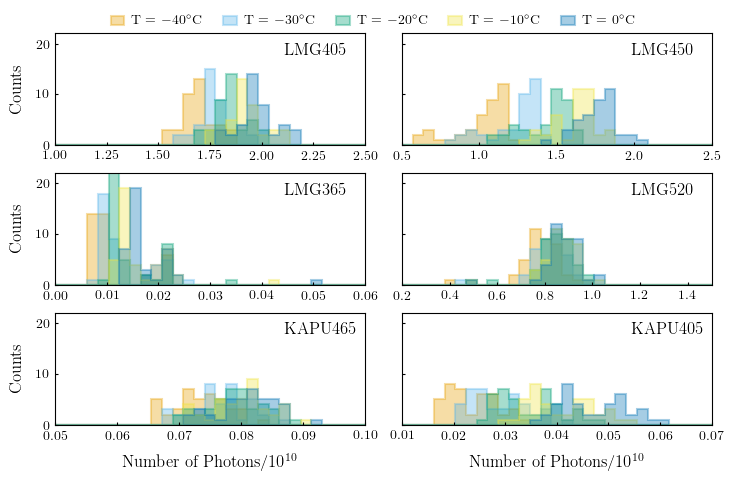

In [26]:
# Wong (2011) colorblind-safe categorical palette — 7 colors
wong_colors = [
    '#E69F00',  # orange
    '#56B4E9',  # sky blue
    '#009E73',  # bluish green
    '#F0E442',  # yellow
    '#0072B2',  # blue
    '#D55E00',  # vermillion
    '#CC79A7',  # reddish purple
]
c_subset = wong_colors[:len(temperatures)]

x_ranges = {
    'LMG450':  (0.5,  2.5),
    'LMG405':  (1.0,  2.5),
    'LMG520':  (0.2,  1.5),
    'LMG365':  (0.0,  0.06),
    'KAPU465': (0.05, 0.1),
    'KAPU405': (0.01, 0.07),
}

fig, axes = plt.subplots(3, 2,
                         figsize=plot_utils.set_size('wide', fraction=1.2, ratio=0.4, subplots=(3, 2)),
                         sharey=True)

for i, ax in enumerate(axes.flat):
    device = devices[i]
    xlo, xhi = x_ranges[device]
    ax.set_xlim(xlo, xhi)
    n = 30
    bins = np.linspace(xlo, xhi, n)

    for j, T in enumerate(temperatures):
        if 'LMG' in device:
            path = f'../output/batch2/pocam_*/hem_*/{device}/photons_54000_{T:.0f}C_2-20.json'
        elif 'KAPU' in device:
            path = f'../output/batch2/pocam_*/hem_*/{device}/photons_54000_{T:.0f}C_default.json'

        filelist = glob.glob(path)

        n_photons_distr = []
        for file in filelist:
            with open(file, 'r') as f:
                data = json.load(f)
            n_photons_distr.append(data['meas_data'][0]['value'])

        ax.hist(np.array(n_photons_distr) / 1e10, bins=bins,
                histtype='stepfilled', lw=1.5,
                color=c_subset[j], alpha=0.35,
                edgecolor=c_subset[j],
                label=f'T = ${T:.0f}^\\circ$C')

    ax.set_ylim(0, 22)

    if i in [4, 5]:
        ax.set_xlabel(r'Number of Photons$/10^{10}$')
    if i in [0, 2, 4]:
        ax.set_ylabel('Counts')

    ax.text(0.74, 0.8, f'{device}', transform=ax.transAxes)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(temperatures),
           bbox_to_anchor=(0.5, 0.94), columnspacing=1.5)
fig.subplots_adjust(hspace=0.25, wspace=0.12)

# plt.savefig('plots/png/number_of_photons_distr_all_Temperatures.png')
# plt.savefig('plots/pdf/number_of_photons_distr_all_Temperatures.pdf')

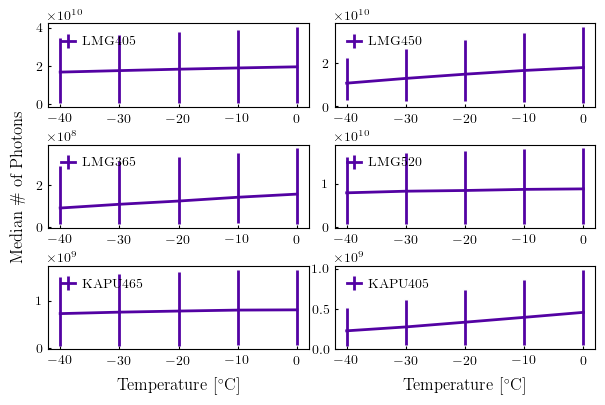

In [13]:
#now let's select all the number of emitter photons for a device and for a temperature and see the distribution
fig, axes = plt.subplots(3,2,figsize=plot_utils.set_size('wide', fraction=1,ratio = 0.4, subplots=(3, 2)))
for i, ax in enumerate(axes.flat):
    device = devices[i]
    n_photons_quantiles = {
        50: [],
        16: [],
        84: [],
    }
    for T in temperatures:
        photons_temp = []
        if "LMG" in device:
            path = f'../output/batch2/pocam_*/hem_*/{device}/photons_54000_{T:.0f}C_2-20.json'
        elif "KAPU" in device:
            path = f'../output/batch2/pocam_*/hem_*/{device}/photons_54000_{T:.0f}C_default.json'

        filelist = glob.glob(path)
        
        for file in filelist:
            with open(file, "r") as f:
                data = json.load(f)
            photons_temp.append(data['meas_data'][0]['value'])
            
        n_photons_quantiles[50].append(np.quantile(photons_temp, .5))
        n_photons_quantiles[16].append(np.quantile(photons_temp, .16))
        n_photons_quantiles[84].append(np.quantile(photons_temp, .84))
            
    ax.errorbar(temperatures,n_photons_quantiles[50],
               yerr=[n_photons_quantiles[16], n_photons_quantiles[84]],
               label = f"{device}")
    if i in [4,5]:
        ax.set_xlabel(r'Temperature [$^\circ$C]')
    if i ==2:
        ax.set_ylabel(r'Median \# of Photons')

    ax.legend(frameon = False,loc = 'upper left', ncol = 1)

fig.subplots_adjust(hspace=0.45, wspace=.1)
# fig.suptitle(f"Distribution of Number of Photons -- T = {T}\,C", y = 0.95)
plt.savefig(f'plots/png/median_numebr_of_photons_vs_T.png')

In [14]:
#check differences with coease/fine settings

In [15]:
coarse_fine = ['1-10', '1-20', '1-40','2-20',]

In [16]:
T = 0

In [17]:
number_of_photons_c_f = {}
FWHM_avg = {}
for c_f in coarse_fine:
    nf = []
    FWHM = []
    filepath = f'../output/batch2/pocam_*/hem_*/LMG405/photons_54000_*C_{c_f}.json'
    files = glob.glob(filepath)
    for file in files:
        with open(file, 'r') as f:
            data = json.load(f)
        nf.append(data['meas_data'][0]['value'])

    filepath_tdc = f'../output/batch2/pocam_*/hem_*/LMG405/tdc_54000_*C_{c_f}.json'
    files = glob.glob(filepath_tdc)
    for file in files:
        with open(file, 'r') as f:
            data = json.load(f)
        FWHM.append( data['meas_data'][1]['value'])
    

    number_of_photons_c_f[c_f] = nf
    FWHM_avg[c_f] = np.mean(FWHM)

In [18]:
FWHM_avg

{'1-10': 4.00509900990099,
 '1-20': 5.7361881188118815,
 '1-40': 8.131442786069652,
 '2-20': 9.616019900497513}

In [19]:
coarse_fine

['1-10', '1-20', '1-40', '2-20']

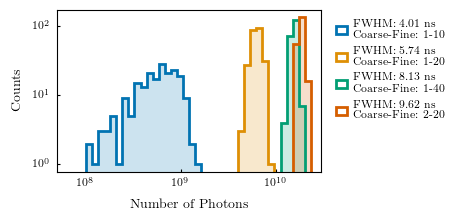

In [49]:
fig, ax = plt.subplots(1,1,figsize=plot_utils.set_size('colums', fraction=1, subplots=(1, 1)))
c_subset = sns.color_palette("colorblind")
for i, c_f in enumerate(coarse_fine):
    bins = np.logspace(8,10.5, 40)
    # bins = np.linspace(1,3e10, 75)
    ax.hist(np.array(number_of_photons_c_f[c_f]),bins = bins, histtype = 'step', color = c_subset[i],lw = 2,label = f'FWHM: {FWHM_avg[c_f]:.2f} ns\nCoarse-Fine: {c_f}')
    ax.hist(np.array(number_of_photons_c_f[c_f]),bins = bins,  color = c_subset[i],alpha = 0.2)
    
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(ncol = 1, bbox_to_anchor = (1.02,1))
# fig.suptitle(f'T = {T}\,C')
ax.set_xlabel('Number of Photons')
ax.set_ylabel('Counts')
ax.set_xlim(5e7,3*10**10)
plt.savefig(f'plots/png/number_of_photons_coarse-fine_allT.png')
plt.savefig(f'plots/pdf/number_of_photons_coarse-fine_allT.pdf')